# OpenAI-based NER Labeling for Indonesian News

This notebook uses OpenAI API (gpt-4o-mini) to automatically label Indonesian news articles with Named Entity Recognition (NER) tags. The output is compatible with HuggingFace model training (e.g., IndoBERT).

**Input**: `data/label studio/1000_news_unlabeled.csv`  
**Outputs**: 
- `openai_labeled_output.json` (training-ready)
- `openai_labeled_enhanced.csv` (human-readable)


# Setup & Configuration

In [85]:
from dotenv import load_dotenv
import os
import json
import csv
import time
import pandas as pd
from openai import OpenAI
from tqdm import tqdm

load_dotenv()

openai_api_key = os.getenv('OPENAI_API_KEY')
if not openai_api_key:
    raise ValueError('OPENAI_API_KEY not found in environment variables')

client = OpenAI(api_key=openai_api_key)
print('OpenAI client initialized successfully')

OpenAI client initialized successfully


In [107]:
"""
KONFIGURASI JUMLAH ARTIKEL UNTUK DIPROSES
"""
num_articles_to_process = 1000

total_available = len(df)
if num_articles_to_process > total_available:
    print(f'Warning: Jumlah yang diminta ({num_articles_to_process}) melebihi data yang tersedia ({total_available})')
    num_articles_to_process = total_available

print(f'Configuration:')
print(f'  Total data tersedia: {total_available}')
print(f'  Akan diproses: {num_articles_to_process}')
print()
print('✓ Konfigurasi siap')

Configuration:
  Total data tersedia: 1000
  Akan diproses: 1000

✓ Konfigurasi siap


# NER Entity Types Definition

Define the 18 NER entity types that will be used for labeling.

In [87]:
ner_entities = {
    'person': 'PER - Nama orang',
    'location': 'LOC - Lokasi geografis',
    'organization': 'ORG - Organisasi',
    'geopolitical': 'GPE - Entitas geopolitik (negara, kota)',
    'date': 'DAT - Tanggal',
    'time': 'TIM - Waktu',
    'money': 'MON - Mata uang/jumlah uang',
    'cardinal': 'CRD - Angka kardinal',
    'ordinal': 'ORD - Angka ordinal',
    'percentage': 'PRC - Persentase',
    'quantity': 'QTY - Kuantitas',
    'event': 'EVT - Acara/peristiwa',
    'facility': 'FAC - Fasilitas',
    'product': 'PRD - Produk',
    'language': 'LAN - Bahasa',
    'law': 'LAW - Hukum/peraturan',
    'religion': 'REG - Agama',
    'woart': 'WOA - Karya seni'
}

print(f'Total NER entity types: {len(ner_entities)}')
for key, desc in ner_entities.items():
    print(f'  - {desc}')

Total NER entity types: 18
  - PER - Nama orang
  - LOC - Lokasi geografis
  - ORG - Organisasi
  - GPE - Entitas geopolitik (negara, kota)
  - DAT - Tanggal
  - TIM - Waktu
  - MON - Mata uang/jumlah uang
  - CRD - Angka kardinal
  - ORD - Angka ordinal
  - PRC - Persentase
  - QTY - Kuantitas
  - EVT - Acara/peristiwa
  - FAC - Fasilitas
  - PRD - Produk
  - LAN - Bahasa
  - LAW - Hukum/peraturan
  - REG - Agama
  - WOA - Karya seni


# Data Loading

Read and validate the input CSV file containing unlabeled news articles.

In [88]:
data_path = '../data/label studio/1000_news_unlabeled.csv'

try:
    df = pd.read_csv(data_path)
    print(f'Data loaded successfully!')
    print(f'Total articles (before cleanup): {len(df)}')
    
    initial_count = len(df)
    df = df.dropna(subset=['fulltext', 'hashtitle'])
    final_count = len(df)
    removed_count = initial_count - final_count
    
    if removed_count > 0:
        print(f'Removed {removed_count} articles with missing text/title')
    
    print(f'Total articles (after cleanup): {final_count}')
    print(f'Columns: {list(df.columns)}')
    print(f'\nFirst article preview:')
    print(f'ID: {df.iloc[0]["hashtitle"]}')
    print(f'Text: {df.iloc[0]["fulltext"][:300]}...')
except FileNotFoundError:
    print(f'ERROR: File not found at {data_path}')
    raise
except Exception as e:
    print(f'ERROR loading data: {e}')
    raise


Data loaded successfully!
Total articles: 1000
Columns: ['hashtitle', 'fulltext']

First article preview:
ID: cac18e1607884f9d4fe7e750b1078c080bb7f052
Text: Sukabumihitz – K-Pop Demon Hunters adalah film animasi musikal Amerika yang dirilis oleh Netflix pada Juni 2025, diproduksi oleh Sony Pictures Animation. Film ini menghadirkan konsep yang benar-benar segar yang menggabungkan budaya K-Pop dengan aksi fantasi tentang pemburu monster. Disutradarai oleh...


# Prompt Engineering

Create the system prompt and example for OpenAI API to guide NER labeling.

In [89]:
def get_api_params(model_name, temperature=0.0, max_tokens=2000):
    """
    Determine correct API parameters based on model name.
    Newer models (gpt-5, gpt-5.x) use max_completion_tokens
    Older models use max_tokens
    """
    params = {
        'model': model_name,
        'temperature': temperature
    }
    
    if model_name.startswith('gpt-5'):
        params['max_completion_tokens'] = max_tokens
    else:
        params['max_tokens'] = max_tokens
    
    return params

print('Compatibility function loaded')

Compatibility function loaded


In [90]:
def build_system_prompt():
    """
    Build the system prompt that defines the AI's role and task.
    """
    system_prompt = """Anda adalah ahli tata bahasa terutama Bahasa Indonesia yang dapat mengetahui struktur kalimat yang bagus. Pada tugas kali ini Anda ditugaskan untuk melabeli berita dari Bahasa Indonesia yang memiliki 18 output Named Entity Recognition.

Berikut adalah 18 jenis entitas yang harus Anda ekstrak:

1. PER (Person) - Nama orang
2. LOC (Location) - Lokasi geografis
3. ORG (Organization) - Organisasi
4. GPE (Geopolitical Entity) - Entitas geopolitik (negara, kota)
5. DAT (Date) - Tanggal
6. TIM (Time) - Waktu
7. MON (Money) - Mata uang/jumlah uang
8. CRD (Cardinal) - Angka kardinal
9. ORD (Ordinal) - Angka ordinal
10. PRC (Percentage) - Persentase
11. QTY (Quantity) - Kuantitas
12. EVT (Event) - Acara/peristiwa
13. FAC (Facility) - Fasilitas
14. PRD (Product) - Produk
15. LAN (Language) - Bahasa
16. LAW (Law) - Hukum/peraturan
17. REG (Religion) - Agama
18. WOA (Work of Art) - Karya seni

PENTING: Setiap prompt meminta labeling untuk SATU artikel saja. Output Anda harus JSON dengan 18 kunci, satu untuk setiap jenis entitas. Nilai setiap kunci adalah daftar string yang berisi entitas yang diekstrak dari teks.

Contoh output JSON yang benar:
{
  \"person\": [\"Maggie Kang\", \"Chris Appelhans\"],
  \"location\": [...],
  \"organization\": [...],
  \"geopolitical\": [...],
  \"date\": [...],
  \"time\": [...],
  \"money\": [...],
  \"cardinal\": [...],
  \"ordinal\": [...],
  \"percentage\": [...],
  \"quantity\": [...],
  \"event\": [...],
  \"facility\": [...],
  \"product\": [...],
  \"language\": [...],
  \"law\": [...],
  \"religion\": [...],
  \"woart\": [...]
}

Hanya kembalikan JSON yang valid, tanpa penjelasan tambahan."""
    return system_prompt

def build_user_prompt(article_text, example_article, example_output):
    """
    Build the user prompt for labeling a single article.
    """
    user_prompt = f"""Berikut adalah contoh artikel yang sudah dilabeli:

CONTOH ARTIKEL:
{example_article}

CONTOH OUTPUT:
{json.dumps(example_output, ensure_ascii=False, indent=2)}

---

Sekarang, labeli artikel berikut dengan output JSON yang memiliki 18 kunci:

ARTIKEL UNTUK DILABELI:
{article_text}

OUTPUT JSON (tanpa penjelasan):"""
    return user_prompt

print('Prompt functions defined successfully')

Prompt functions defined successfully


# Example Article & Output

Define the example article and output that will be used in prompts to guide the AI.

In [91]:
example_article = """Sukabumihitz – K-Pop Demon Hunters adalah film animasi musikal Amerika yang dirilis oleh Netflix pada Juni 2025, diproduksi oleh Sony Pictures Animation. Film ini menghadirkan konsep yang benar-benar segar yang menggabungkan budaya K-Pop dengan aksi fantasi tentang pemburu monster. Disutradarai oleh Maggie Kang dan Chris Appelhans, film ini berhasil mencuri perhatian dengan visual yang memukau, lagu-lagu yang adiktif, dan cerita yang penuh humor serta emosi.

Sinopsis Film Animasi K-Pop Demon Hunters

Film ini mengisahkan tentang Huntrix, sebuah grup K-Pop wanita yang terdiri dari tiga anggota: Rumi (Arden Cho), Mira (May Hong), dan Zoey (Ji-young Yoo). Di balik sorotan panggung dan gemerlap ketenaran, mereka menyimpan rahasia besar. Mereka adalah pemburu monster yang bertugas menjaga dunia dari ancaman supranatural yang dipimpin oleh raja dari para monster, Gwi-Ma (Lee Byung-hun)."""

example_output = {
    'person': ['Maggie Kang', 'Chris Appelhans', 'Rumi', 'Arden Cho', 'Mira', 'May Hong', 'Zoey', 'Ji-young Yoo', 'Gwi-Ma', 'Lee Byung-hun'],
    'location': ['Honmoon'],
    'organization': ['Netflix', 'Sony Pictures Animation', 'Huntrix'],
    'geopolitical': ['Amerika', 'Korea'],
    'date': ['Juni 2025'],
    'time': [],
    'money': [],
    'cardinal': ['tiga'],
    'ordinal': [],
    'percentage': [],
    'quantity': [],
    'event': [],
    'facility': [],
    'product': [],
    'language': [],
    'law': [],
    'religion': [],
    'woart': ['K-Pop Demon Hunters', 'Spider-Man: Into the Spider-Verse']
}

print('Example article and output defined successfully')

Example article and output defined successfully


In [92]:
def label_article_with_openai(article_text, model, max_retries=3, retry_delay=2):
    """
    Label a single article using OpenAI API with retry logic.
    
    Args:
        article_text: The news article text to be labeled
        model: The OpenAI model to use
        max_retries: Maximum number of retries on failure
        retry_delay: Delay between retries in seconds
    
    Returns:
        dict: Labeled output with 18 NER entity types or error info
    """
    system_prompt = build_system_prompt()
    user_prompt = build_user_prompt(article_text, example_article, example_output)
    
    for attempt in range(max_retries):
        try:
            api_params = get_api_params(model, temperature=0.0, max_tokens=2000)
            api_params['messages'] = [
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': user_prompt}
            ]
            response = client.chat.completions.create(**api_params)
            
            response_text = response.choices[0].message.content.strip()
            
            try:
                labeled_output = json.loads(response_text)
                
                if not all(key in labeled_output for key in ner_entities.keys()):
                    missing_keys = set(ner_entities.keys()) - set(labeled_output.keys())
                    raise ValueError(f'Missing keys in response: {missing_keys}')
                
                return labeled_output
            except json.JSONDecodeError:
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                else:
                    return {'error': 'Invalid JSON response', 'raw_response': response_text[:500]}
        
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
                continue
            else:
                return {'error': str(e)[:200]}
    
    return {'error': 'Max retries exceeded'}

print('Label function defined successfully')


Label function defined successfully


# Process All Articles

Run the batch labeling process for all articles with progress tracking.

In [108]:
labeled_results = []
errors = []
total_articles = len(df)
api_call_count = 0
model = 'gpt-5.4-mini'

print(f'Starting labeling process for {total_articles} articles...')
print('---')

for idx, row in tqdm(df.iloc[:num_articles_to_process].iterrows(), total=num_articles_to_process, desc='Labeling articles'):
    article_id = row['hashtitle']
    article_text = row['fulltext']
    
    labeled_output = label_article_with_openai(article_text, model)
    api_call_count += 1
    
    if 'error' in labeled_output:
        errors.append({
            'article_id': article_id,
            'index': idx,
            'error': labeled_output['error']
        })
    
    labeled_results.append({
        'article_id': article_id,
        'fulltext': article_text,
        'labels': labeled_output
    })

print(f'\nLabeling complete!')
print(f'Total API calls: {api_call_count}')
print(f'Successful: {total_articles - len(errors)}')
print(f'Errors: {len(errors)}')

Starting labeling process for 1000 articles...
---


Labeling articles: 100%|██████████| 1000/1000 [57:42<00:00,  3.46s/it]   


Labeling complete!
Total API calls: 1000
Successful: 999
Errors: 1


# Output Generation

Generate and save the labeled output in JSON and CSV formats.

In [111]:
import os
from pathlib import Path

output_dir = Path('../data/openai_labeled_output')

json_output_path = output_dir / 'openai_labeled_output.json'
csv_output_path = output_dir / 'openai_labeled_enhanced.csv'

with open(json_output_path, 'w', encoding='utf-8') as f:
    json.dump(labeled_results, f, ensure_ascii=False, indent=2)
print(f'JSON output saved to: {json_output_path}')

with open(csv_output_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['hashtitle', 'fulltext', 'labels'])
    writer.writeheader()
    for result in labeled_results:
        fulltext = result['fulltext']
        if fulltext is None or (isinstance(fulltext, float) and fulltext != fulltext):
            fulltext = ''
        elif isinstance(fulltext, str):
            fulltext = fulltext[:500]
        else:
            fulltext = str(fulltext)[:500]
        
        writer.writerow({
            'hashtitle': result['article_id'],
            'fulltext': fulltext,
            'labels': json.dumps(result['labels'], ensure_ascii=False)
        })
print(f'CSV output saved to: {csv_output_path}')


JSON output saved to: ../data/openai_labeled_output/openai_labeled_output.json
CSV output saved to: ../data/openai_labeled_output/openai_labeled_enhanced.csv


# Validation & Quality Check

Verify the output structure and generate quality assurance report.

In [112]:
print('=== QUALITY ASSURANCE REPORT ===')
print()

total_processed = len(labeled_results)
successful = total_processed - len(errors)
success_rate = (successful / total_processed * 100) if total_processed > 0 else 0

print(f'Total Articles Processed: {total_processed}')
print(f'Successful: {successful} ({success_rate:.1f}%)')
print(f'Failed (API errors): {len(errors)}')
print()

if errors:
    print('Failed Articles (first 5):')
    for error in errors[:5]:
        print(f"  - ID: {error['article_id'][:40]}... | Error: {error['error'][:60]}...")
    if len(errors) > 5:
        print(f"  ... and {len(errors) - 5} more")
print()

nan_or_none_articles = []
entity_stats = {entity_key: 0 for entity_key in ner_entities.keys()}
malformed_count = 0

for result in labeled_results:
    labels = result['labels']
    fulltext = result['fulltext']
    
    if fulltext is None or (isinstance(fulltext, float) and fulltext != fulltext):
        nan_or_none_articles.append(result['article_id'])
    
    if 'error' in labels:
        malformed_count += 1
        continue
    for entity_key in ner_entities.keys():
        if entity_key in labels and isinstance(labels[entity_key], list):
            entity_stats[entity_key] += len(labels[entity_key])

if nan_or_none_articles:
    print(f'Articles with missing/NaN text: {len(nan_or_none_articles)}')
    for article_id in nan_or_none_articles[:3]:
        print(f"  - {article_id}")
    if len(nan_or_none_articles) > 3:
        print(f"  ... and {len(nan_or_none_articles) - 3} more")
    print()

print('Entity Type Distribution:')
sorted_entities = sorted(entity_stats.items(), key=lambda x: x[1], reverse=True)
for entity_key, count in sorted_entities:
    entity_desc = ner_entities[entity_key]
    print(f"  {entity_desc}: {count}")

print()
print(f'Malformed Labels (errors in response): {malformed_count}')
print()
print('Sample Labeled Article:')
if labeled_results:
    sample = labeled_results[0]
    print(f"ID: {sample['article_id'][:60]}")
    print(f"Text (first 200 chars): {sample['fulltext'][:200] if sample['fulltext'] else '[EMPTY]'}...")
    print(f"Labels: {json.dumps(sample['labels'], ensure_ascii=False, indent=2)}"[:500])


=== QUALITY ASSURANCE REPORT ===

Total Articles Processed: 1000
Successful: 999 (99.9%)
Failed (API errors): 1

Failed Articles (first 5):
  - ID: 494e4cf5d5022df1a8f1b58c4f68a8edf2786709... | Error: Invalid JSON response...

Articles with missing/NaN text: 1
  - 403562962f232118ff419d35ec352a4c32581490

Entity Type Distribution:
  ORG - Organisasi: 6660
  LOC - Lokasi geografis: 4032
  PER - Nama orang: 3870
  CRD - Angka kardinal: 3525
  GPE - Entitas geopolitik (negara, kota): 2878
  DAT - Tanggal: 2462
  EVT - Acara/peristiwa: 1801
  PRD - Produk: 1284
  FAC - Fasilitas: 1004
  MON - Mata uang/jumlah uang: 514
  QTY - Kuantitas: 499
  ORD - Angka ordinal: 464
  LAW - Hukum/peraturan: 454
  TIM - Waktu: 384
  PRC - Persentase: 300
  REG - Agama: 243
  WOA - Karya seni: 190
  LAN - Bahasa: 71

Malformed Labels (errors in response): 1

Sample Labeled Article:
ID: cac18e1607884f9d4fe7e750b1078c080bb7f052
Text (first 200 chars): Sukabumihitz – K-Pop Demon Hunters adalah film animasi mu

# Model Comparison & Performance Analysis

models reference : https://developers.openai.com/api/docs/pricing?latest-pricing=standard

In [96]:
num_articles_for_comparison = 3
models_to_compare = [
    'gpt-4o-mini',
    'gpt-4-turbo',
    'gpt-5.4-mini',
    'gpt-5.4'
]

print(f'Comparing {num_articles_for_comparison} articles using {len(models_to_compare)} models')
print(f'Models: {models_to_compare}')

Comparing 3 articles using 4 models
Models: ['gpt-4o-mini', 'gpt-4-turbo', 'gpt-5.4-mini', 'gpt-5.4']


In [97]:
import time
from collections import defaultdict

comparison_results = []
model_metrics = defaultdict(lambda: {'total_time': 0, 'success_count': 0, 'error_count': 0, 'entity_counts': []})

sample_articles = df.iloc[:num_articles_for_comparison]

print(f'Starting model comparison for {num_articles_for_comparison} articles')
print('=' * 80)

for idx, (article_idx, row) in enumerate(sample_articles.iterrows(), 1):
    article_text = row['fulltext']
    print(f'\nProcessing Article {idx}/{num_articles_for_comparison}: {article_text[:60]}...')
    print('-' * 80)
    
    article_results = {
        'article_id': article_idx,
        'text_preview': article_text[:100],
        'models': {}
    }
    
    for model_name in models_to_compare:
        print(f'  Testing {model_name}...', end=' ', flush=True)
        start_time = time.time()
        
        try:
            system_prompt = build_system_prompt()
            user_prompt = build_user_prompt(article_text, example_article, example_output)
            
            api_params = get_api_params(model_name, temperature=0.0, max_tokens=2000)
            api_params['messages'] = [
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': user_prompt}
            ]
            response = client.chat.completions.create(**api_params)
            
            elapsed = time.time() - start_time
            response_text = response.choices[0].message.content.strip()
            
            try:
                labeled_data = json.loads(response_text)
                
                if not all(key in labeled_data for key in ner_entities.keys()):
                    missing_keys = set(ner_entities.keys()) - set(labeled_data.keys())
                    raise ValueError(f'Missing keys in response: {missing_keys}')
                
            except json.JSONDecodeError:
                labeled_data = {'error': 'Invalid JSON response', 'raw_response': response_text[:500]}
            
            entity_count = sum(len(v) if isinstance(v, list) else 0 for v in labeled_data.values())
            
            article_results['models'][model_name] = {
                'status': 'success',
                'time': elapsed,
                'entity_count': entity_count,
                'result': labeled_data
            }
            
            model_metrics[model_name]['total_time'] += elapsed
            model_metrics[model_name]['success_count'] += 1
            model_metrics[model_name]['entity_counts'].append(entity_count)
            
            print(f'OK ({elapsed:.2f}s, {entity_count} entities)')
            
        except Exception as e:
            elapsed = time.time() - start_time
            article_results['models'][model_name] = {
                'status': 'error',
                'time': elapsed,
                'error': str(e)[:100]
            }
            model_metrics[model_name]['error_count'] += 1
            print(f'ERROR: {str(e)[:40]}')
    
    comparison_results.append(article_results)

print('\n' + '=' * 80)
print('Comparison completed')


Starting model comparison for 3 articles

Processing Article 1/3: Sukabumihitz – K-Pop Demon Hunters adalah film animasi musik...
--------------------------------------------------------------------------------
  Testing gpt-4o-mini... OK (5.88s, 26 entities)
  Testing gpt-4-turbo... OK (9.62s, 33 entities)
  Testing gpt-5.4-mini... OK (2.38s, 34 entities)
  Testing gpt-5.4... OK (4.42s, 34 entities)

Processing Article 2/3: 02 Jul 2025, 08:18 WIB  Suasana sekitar Pasar Ciputat (IDN T...
--------------------------------------------------------------------------------
  Testing gpt-4o-mini... OK (4.23s, 23 entities)
  Testing gpt-4-turbo... OK (9.47s, 22 entities)
  Testing gpt-5.4-mini... OK (2.82s, 31 entities)
  Testing gpt-5.4... OK (4.51s, 30 entities)

Processing Article 3/3: MANILA, Philippines — When he found out one morning that Lia...
--------------------------------------------------------------------------------
  Testing gpt-4o-mini... OK (4.27s, 21 entities)
  Testing gpt-

In [98]:
import pandas as pd
import numpy as np

print('\n' + '=' * 80)
print('COMPARISON ANALYSIS')
print('=' * 80 + '\n')

summary_data = []
for model_name in models_to_compare:
    metrics = model_metrics[model_name]
    total_attempts = metrics['success_count'] + metrics['error_count']
    
    avg_time = metrics['total_time'] / metrics['success_count'] if metrics['success_count'] > 0 else 0
    avg_entities = np.mean(metrics['entity_counts']) if metrics['entity_counts'] else 0
    success_rate = (metrics['success_count'] / total_attempts * 100) if total_attempts > 0 else 0
    
    summary_data.append({
        'Model': model_name,
        'Success': f"{success_rate:.1f}%",
        'Avg Time (s)': f"{avg_time:.2f}",
        'Avg Entities': f"{avg_entities:.1f}",
        'Errors': metrics['error_count']
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()

print('\nPERFORMANCE SUMMARY:')
print('-' * 80)

fastest_model = min(models_to_compare, 
                   key=lambda m: model_metrics[m]['total_time'] / max(model_metrics[m]['success_count'], 1))
print(f'Fastest: {fastest_model}')

most_entities = max(models_to_compare,
                   key=lambda m: np.mean(model_metrics[m]['entity_counts']) if model_metrics[m]['entity_counts'] else 0)
print(f'Most Entities: {most_entities}')



COMPARISON ANALYSIS

       Model Success Avg Time (s) Avg Entities  Errors
 gpt-4o-mini  100.0%         4.79         23.3       0
 gpt-4-turbo  100.0%         8.87         26.3       0
gpt-5.4-mini  100.0%         2.53         34.0       0
     gpt-5.4  100.0%         4.49         33.7       0


PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
Fastest: gpt-5.4-mini
Most Entities: gpt-5.4-mini


In [106]:
article_index = 2

if article_index < len(comparison_results):
    result = comparison_results[article_index]
    
    print('\n' + '=' * 100)
    print(f"DETAILED MODEL OUTPUT COMPARISON - Article {article_index + 1}")
    print('=' * 100)
    print(f"\nArticle Text:\n{result['text_preview']}...\n")
    
    entity_types = list(ner_entities.keys())
    
    for entity_type in entity_types:
        print('\n' + '-' * 100)
        print(f"{entity_type.upper()} ({ner_entities[entity_type]})")
        print('-' * 100)
        
        for model_name in models_to_compare:
            if model_name in result['models']:
                model_result = result['models'][model_name]
                
                if model_result['status'] == 'success':
                    labeled_data = model_result['result']
                    entities = labeled_data.get(entity_type, [])
                    
                    if entities:
                        entities_str = ', '.join(f'\"{e}\"' for e in entities)
                        print(f"  {model_name:20s}: {entities_str}")
                    else:
                        print(f"  {model_name:20s}: [None]")
                else:
                    print(f"  {model_name:20s}: ERROR - {model_result.get('error', 'Unknown error')}")
    
    print('\n' + '=' * 100)
    print("SUMMARY BY MODEL")
    print('=' * 100)
    
    for model_name in models_to_compare:
        if model_name in result['models']:
            model_result = result['models'][model_name]
            print(f"\n{model_name}:")
            print(f"  Status: {model_result['status']}")
            print(f"  Response Time: {model_result['time']:.2f}s")
            print(f"  Total Entities: {model_result['entity_count']}")
            
            if model_result['status'] == 'success':
                labeled_data = model_result['result']
                entity_breakdown = {}
                
                for entity_type in entity_types:
                    entities = labeled_data.get(entity_type, [])
                    if entities:
                        entity_breakdown[entity_type] = len(entities)
                
                if entity_breakdown:
                    print(f"  Entities by Type:")
                    for entity_type, count in sorted(entity_breakdown.items()):
                        print(f"    - {entity_type}: {count}")
else:
    print('No comparison results available. Run model comparison cells first.')



DETAILED MODEL OUTPUT COMPARISON - Article 3

Article Text:
MANILA, Philippines — When he found out one morning that Liam Payne had died, Isaac Jeff Coloma trie...


----------------------------------------------------------------------------------------------------
PERSON (PER - Nama orang)
----------------------------------------------------------------------------------------------------
  gpt-4o-mini         : "Liam Payne", "Isaac Jeff Coloma"
  gpt-4-turbo         : "Liam Payne", "Isaac Jeff Coloma", "Jeff"
  gpt-5.4-mini        : "Liam Payne", "Isaac Jeff Coloma", "Jeff", "Coloma"
  gpt-5.4             : "Liam Payne", "Isaac Jeff Coloma", "Coloma", "Jeff"

----------------------------------------------------------------------------------------------------
LOCATION (LOC - Lokasi geografis)
----------------------------------------------------------------------------------------------------
  gpt-4o-mini         : "Buenos Aires", "Argentina", "France", "Pasay City"
  gpt-4-turbo   

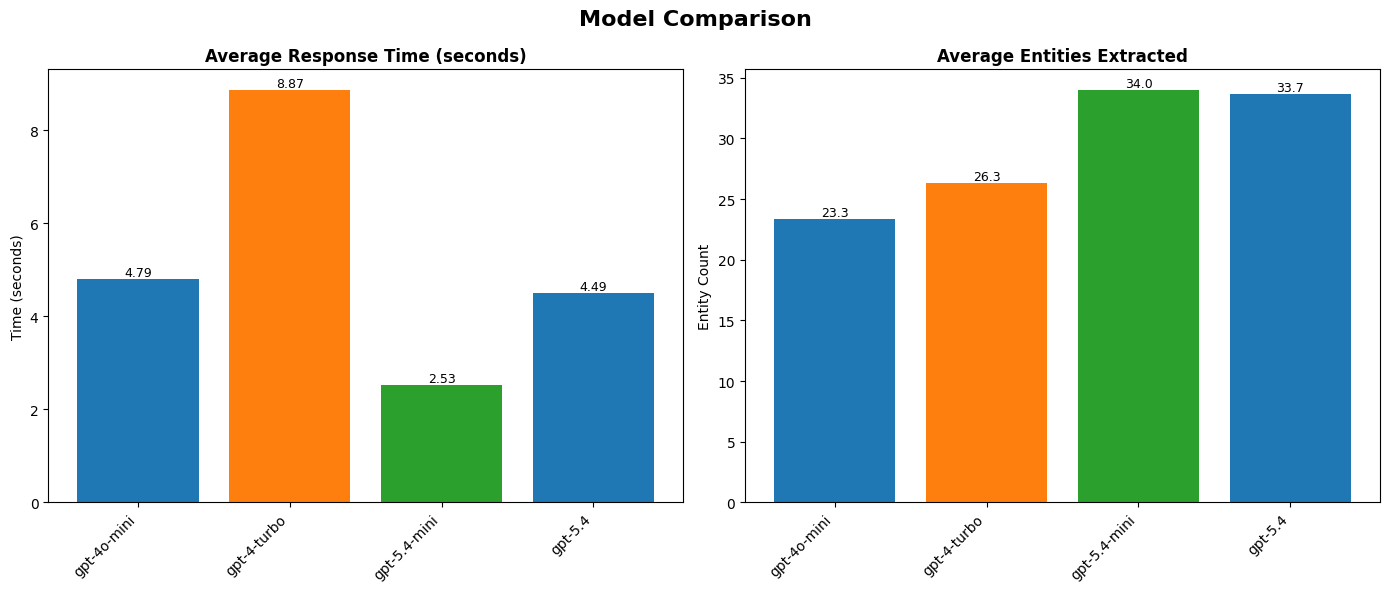

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

model_names = list(models_to_compare)
avg_times = []
avg_entities = []
success_rates = []

for model in model_names:
    metrics = model_metrics[model]
    total = metrics['success_count'] + metrics['error_count']
    
    avg_times.append(metrics['total_time'] / metrics['success_count'] if metrics['success_count'] > 0 else 0)
    avg_entities.append(np.mean(metrics['entity_counts']) if metrics['entity_counts'] else 0)
    success_rates.append(metrics['success_count'] / total * 100 if total > 0 else 0)

ax1 = axes[0] 
bars1 = ax1.bar(model_names, avg_times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Average Response Time (seconds)', fontweight='bold')
ax1.set_ylabel('Time (seconds)')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = axes[1] 
bars2 = ax2.bar(model_names, avg_entities, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Average Entities Extracted', fontweight='bold')
ax2.set_ylabel('Entity Count')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()